# Задание

На основе анонимизированных данных цифрового следа обучающихся в электронном обучающем курсе проверить гипотезу о наличии связи между активными действиями в электронном курсе и просмотрами. При наличии связи провести регрессионный анализ и подобрать оптимальный вид и параметры функциональной зависимости между переменными Активные действия и Просмотры. Сделать вывод.

Под **просмотрами** считать следующие названия событий: *['Модуль курса просмотрен', 'HotPot attempt reviewed', 'Страница вики просмотрена', 'Показана карта страниц Вики', 'Версия страницы вики просмотрена', 'Комментарии просмотрены',
'Запись просмотрена', 'Отзыв просмотрен', 'Страница состояния представленного ответа просмотрена', 'Глава просмотрена',
'Содержимое страницы просмотрено', 'Вопрос просмотрен', 'Ответ на задание типа «Эссе» просмотрен', 'Отчет просмотрен',
'Работа просмотрена', 'Попытка теста просмотрена', 'Завершенная попытка теста просмотрена', 'Сводка попытки теста просмотрена', 'Тема просмотрена', 'Отчет по пользователю просмотрен', 'Сессии просмотрены']*

Под **активными действиями** считать следующие названия событий: *['Ответ на анкету отправлен', 'Запись создана', 'Запись обновлена', 'Комментарий создан', 'Страница вики создана', 'Страница вики обновлена', 'Комментарий создан', 'Категория создана', 'Категория обновлена', 'Комментарий создан', 'Запись создана', 'Запись обновлена', 'Работа представлена.', 'Представленный ответ обновлен.', 'Комментарий создан', 'Дан ответ на вопрос', 'Лекция закончена', 'Ответ представлен', 'Ответ на опрос добавлен', 'Sco запущен', 'Посещаемость отмечена студентом', 'Работа оценена', 'Работа переоценена', 'Представление работы создано', 'Работа была загружена', 'Работа обновлена', 'Попытка теста завершена и отправлена на оценку', 'Тема создана', 'Сообщение создано', 'Отправлено сообщение']*

**Алгоритм действий:**
1. Считать данные.
2. Исключить данные до начала (до 01.09.2023) и после окончания (до 15.01.2024) осеннего семестра.
3. Агрегировать данные для каждого пользователя по количеству активных действий и просмотров в течение осеннего семестра.
4. Проверить гипотезу независимости критерием хи-квадрат Пирсона (учесть замечание по использованию критерия: $\nu_{ij}>5$).
5. Сделать вывод.
6. При наличии статистически значимой зависимости между количеством активных действий и просмотров, провести регрессионный анализ:
    - вычислить выборочный коэффициент корреляции Пирсона между количеством активных действий и просмотров, проверить его статистическую значимость, сделать вывод о возможности приближения зависимости между количеством активных действий и просмотров линейной функцией;
    - построить линейную регрессию количества активных действий от просмотров, оценить статистическую значимость коэффициентов уравнения линейной регрессии и значимость всего уравнения в целом;
    - проверить выполнение условия адекватности каждой из полученных моделей регрессии (нормальность распределения регрессионных остатков), построив Q-Q график;
    - выбрать еще 2-3 функциональные формы (квадратическая, логарифмическая, экспоненциальная, обратная и т.д.) зависимости количества активных действий от просмотров, оценить коэффициенты для каждого вида зависимости,  проверить выполнение условия адекватности моделей;
    - выбрать оптимальную модель на основании коэффициента детерминации;
    - с помощью оптимальной модели найти прогноз количества активных действий в курсе, произвольным образом задав для него значение просмотров.
7. Сделать выводы.

In [19]:
views = ['Модуль курса просмотрен', 'HotPot attempt reviewed', 'Страница вики просмотрена', 'Показана карта страниц Вики', 'Версия страницы вики просмотрена', 'Комментарии просмотрены',
'Запись просмотрена', 'Отзыв просмотрен', 'Страница состояния представленного ответа просмотрена', 'Глава просмотрена',
'Содержимое страницы просмотрено', 'Вопрос просмотрен', 'Ответ на задание типа «Эссе» просмотрен', 'Отчет просмотрен',
'Работа просмотрена', 'Попытка теста просмотрена', 'Завершенная попытка теста просмотрена', 'Сводка попытки теста просмотрена', 'Тема просмотрена', 'Отчет по пользователю просмотрен', 'Сессии просмотрены']
active = ['Ответ на анкету отправлен', 'Запись создана', 'Запись обновлена', 'Комментарий создан', 'Страница вики создана', 'Страница вики обновлена', 'Комментарий создан', 'Категория создана', 'Категория обновлена', 'Комментарий создан', 'Запись создана', 'Запись обновлена', 'Работа представлена.', 'Представленный ответ обновлен.', 'Комментарий создан', 'Дан ответ на вопрос', 'Лекция закончена', 'Ответ представлен', 'Ответ на опрос добавлен', 'Sco запущен', 'Посещаемость отмечена студентом', 'Работа оценена', 'Работа переоценена', 'Представление работы создано', 'Работа была загружена', 'Работа обновлена', 'Попытка теста завершена и отправлена на оценку', 'Тема создана', 'Сообщение создано', 'Отправлено сообщение']

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy.stats import chi2_contingency, pearsonr, boxcox
import statsmodels.api as sm

In [21]:
df = pd.read_csv('df_var_10.csv')
df["Время"] = pd.to_datetime(df["Время"], format="%Y-%m-%d %H:%M:%S")

In [22]:
# 2. Исключить данные до 01.09.2023 и после 15.01.2024
start_date = pd.to_datetime('2023-09-01')
end_date = pd.to_datetime('2024-01-15')
df_filtered = df[(df['Время'] >= start_date) & (df['Время'] <= end_date)]
print(f'Размер отфильтрованного датасета: {df_filtered.shape}')

Размер отфильтрованного датасета: (98355, 7)


In [23]:
# 3. Агрегировать данные по пользователям
views_count = df_filtered[df_filtered['Название события'].isin(views)].groupby('Полное имя пользователя').size().reset_index(name='Просмотры')
active_count = df_filtered[df_filtered['Название события'].isin(active)].groupby('Полное имя пользователя').size().reset_index(name='Активные действия')
df_agg = pd.merge(views_count, active_count, on='Полное имя пользователя', how='outer').fillna(0)
df_agg['Просмотры'] = df_agg['Просмотры'].astype(int)
df_agg['Активные действия'] = df_agg['Активные действия'].astype(int)
print(df_agg.head())

            Полное имя пользователя  Просмотры  Активные действия
0  0013cbbe04f4ef7e3b68427130879265        221                 51
1  005b103b8dab7a44c8fa0032dd3ce71e        163                 20
2  009811d0356ea306907acb74f86132b4        143                 39
3  009844f1c773a4576914819aeb9aadc3        469                  0
4  00c8ab9c7d42d289a27de525176419bf         50                  1


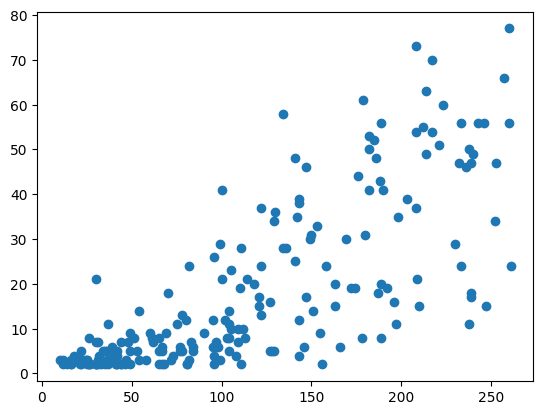

In [24]:
Q1 = df_agg['Просмотры'].quantile(0.25) 
Q3 = df_agg['Просмотры'].quantile(0.75)
IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR  
upper_bound = Q3 + 1.5 * IQR  

df_agg = df_agg[
    (df_agg['Просмотры'] >= lower_bound) & 
    (df_agg['Просмотры'] <= upper_bound)
]

outliers_mask = (df_agg['Активные действия'] < 2)# адекватные модели получаются только при такой обрезке
df_agg = df_agg[~outliers_mask].copy()

plt.scatter(df_agg['Просмотры'], df_agg['Активные действия'])

In [33]:
# 4. Проверить гипотезу независимости критерием хи-квадрат
from scipy.stats import chi2_contingency

views_edges = [0, 100, 150, 200, np.inf] 
active_edges = [10, 20,  np.inf]   

df_agg['views_bin'] = pd.cut(df_agg['Просмотры'], bins=views_edges)
df_agg['active_bin'] = pd.cut(df_agg['Активные действия'], bins=active_edges)

contingency = pd.crosstab(df_agg['views_bin'], df_agg['active_bin'])

if (contingency.values < 5).any():
    print("Внимание: есть ячейки с частотой < 5")
else:
    print("Условие выполнено: все ячейки ≥ 5")

chi2, p, dof, expected = chi2_contingency(contingency)
print(f'Chi2: {chi2}')
print(f'p-value: {p}')
print(f'DOF: {dof}')
print('Ожидаемые частоты:\n', expected)

if p<=0.05:
    print("Гипотеза о независимости отверграется")
else:
    print("Гипотеза о независимости не отверграется")
contingency

Условие выполнено: все ячейки ≥ 5
Chi2: 8.182814653595546
p-value: 0.04238077607160806
DOF: 3
Ожидаемые частоты:
 [[ 4.29  8.71]
 [ 9.57 19.43]
 [ 8.25 16.75]
 [10.89 22.11]]
Гипотеза о независимости отверграется


active_bin,"(10.0, 20.0]","(20.0, inf]"
views_bin,,
"(0.0, 100.0]",7,6
"(100.0, 150.0]",11,18
"(150.0, 200.0]",10,15
"(200.0, inf]",5,28


In [26]:
corr, p_corr = pearsonr(df_agg['Просмотры'], df_agg['Активные действия'])
print(f'Коэффициент корреляции Пирсона: {corr}')
print(f'p-value: {p_corr}')

if p_corr < 0.05:
    print('Корреляция статистически значима.')
else:
    print('Корреляция не значима.')

Коэффициент корреляции Пирсона: 0.7682547284370594
p-value: 1.4850692888571137e-42
Корреляция статистически значима.


Оптимальное lambda для Box-Cox: -0.14357551163764584
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                     389.8
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           9.44e-50
Time:                        00:00:19   Log-Likelihood:                -116.00
No. Observations:                 212   AIC:                             236.0
Df Residuals:                     210   BIC:                             242.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

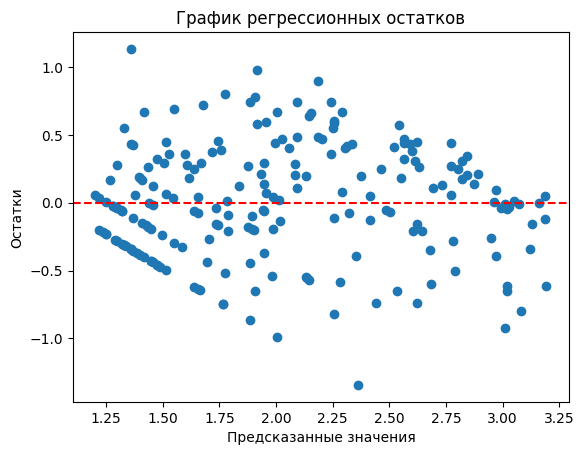

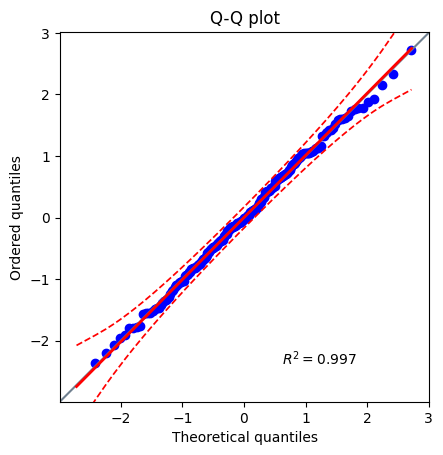

In [27]:
y = df_agg['Активные действия'] + 1
y_boxcox, lambda_boxcox = boxcox(y)
print(f'Оптимальное lambda для Box-Cox: {lambda_boxcox}')

X_lin = sm.add_constant(df_agg['Просмотры'])
model_lin = sm.OLS(y_boxcox, X_lin).fit()
print(model_lin.summary())

plt.scatter(model_lin.fittedvalues, model_lin.resid)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График регрессионных остатков')
plt.axhline(0, color='red', linestyle='--')
plt.show()

pg.qqplot(model_lin.resid)
plt.title('Q-Q plot')
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     207.2
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           2.50e-50
Time:                        00:00:20   Log-Likelihood:                -111.40
No. Observations:                 212   AIC:                             228.8
Df Residuals:                     209   BIC:                             238.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9225      0.084     10.952      0.0

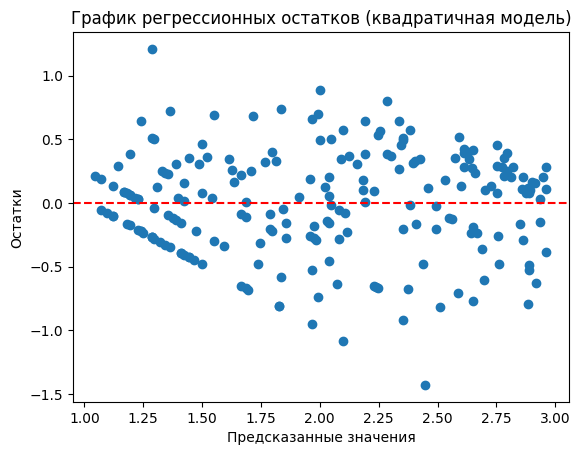

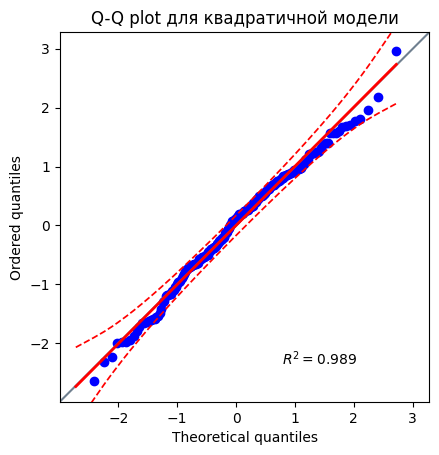

In [28]:
# Квадратичная модель
df_agg['views_sq'] = df_agg['Просмотры'] ** 2
X_quad = sm.add_constant(df_agg[['Просмотры', 'views_sq']])
model_quad = sm.OLS(y_boxcox, X_quad).fit()
print(model_quad.summary())

# График остатков
plt.scatter(model_quad.fittedvalues, model_quad.resid)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График регрессионных остатков (квадратичная модель)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

# Q-Q plot
pg.qqplot(model_quad.resid, dist='norm', confidence=0.95)
plt.title('Q-Q plot для квадратичной модели')
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     200.6
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           2.35e-49
Time:                        00:00:20   Log-Likelihood:                -113.67
No. Observations:                 212   AIC:                             233.3
Df Residuals:                     209   BIC:                             243.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3504      0.362      0.968      0.3

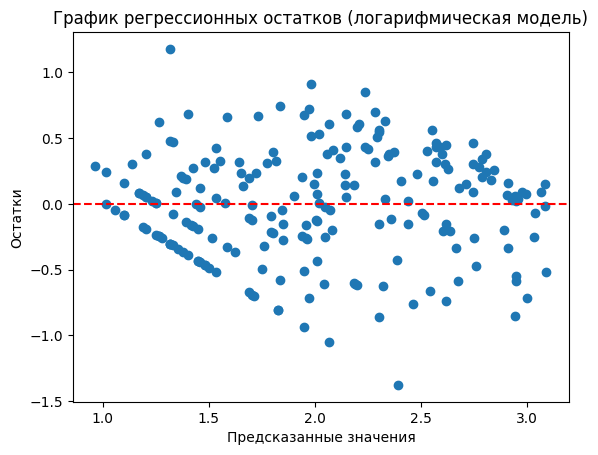

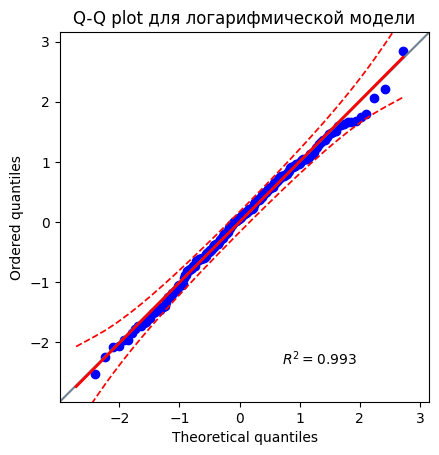

In [29]:
# Логарифмическая
df_agg['views_log'] = np.log(df_agg['Просмотры'] + 1)
X_log = sm.add_constant(df_agg[['views_log','Просмотры']])
model_log = sm.OLS(y_boxcox, X_log).fit()
print(model_log.summary())

# График остатков
plt.scatter(model_log.fittedvalues, model_log.resid)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График регрессионных остатков (логарифмическая модель)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

# Q-Q plot
pg.qqplot(model_log.resid, dist='norm', confidence=0.95)
plt.title('Q-Q plot для логарифмической модели')
plt.show()

In [30]:
models = {
    'Линейная': model_lin,
    'Квадратичная': model_quad,
    'Логарифмическая': model_log
}
best_model_name = max(models, key=lambda name: models[name].rsquared)
best_model = models[best_model_name]
best_model_name

'Квадратичная'

In [31]:
from scipy.special import inv_boxcox
prosmotry_input = 10  

X_new = pd.DataFrame({
    'const': [1],
    'views_sq': [prosmotry_input**2],
    'Просмотры': [prosmotry_input]
})

# предсказание в преобразованной шкале 
y_pred_boxcox = best_model.predict(X_new)[0]

# Обратное преобразование BoxCox 
from scipy.special import inv_boxcox
y_pred = inv_boxcox(y_pred_boxcox, lambda_boxcox) - 1  # вычитаем 1, т.к. мы добавляли 1 ранее

print(f"Прогноз количества активных действий при {prosmotry_input} просмотрах: {np.round(y_pred, 2)}")

Прогноз количества активных действий при 10 просмотрах: 12.81


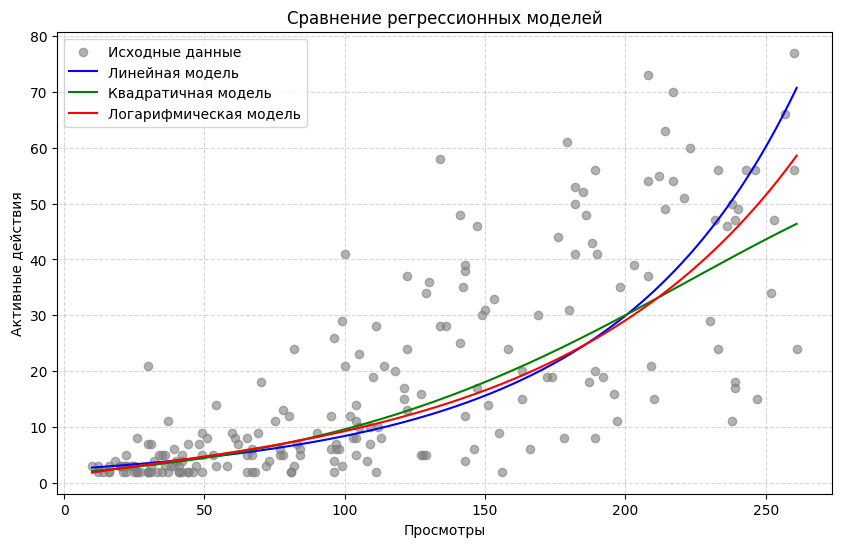

In [32]:
x_vals = df_agg['Просмотры'].values
y_vals = df_agg['Активные действия'].values

y_orig = inv_boxcox(y_boxcox, lambda_boxcox) - 1

x_grid = np.linspace(x_vals.min(), x_vals.max(), 300)


X_lin_grid = sm.add_constant(x_grid)
y_lin_pred_bc = model_lin.predict(X_lin_grid)
y_lin_pred = inv_boxcox(y_lin_pred_bc, lambda_boxcox) - 1


X_quad_grid = sm.add_constant(np.column_stack([x_grid, x_grid**2]))
y_quad_pred_bc = model_quad.predict(X_quad_grid)
y_quad_pred = inv_boxcox(y_quad_pred_bc, lambda_boxcox) - 1


X_log_grid = sm.add_constant(np.column_stack([np.log(x_grid + 1), x_grid]))
y_log_pred_bc = model_log.predict(X_log_grid)
y_log_pred = inv_boxcox(y_log_pred_bc, lambda_boxcox) - 1


plt.figure(figsize=(10, 6))
plt.scatter(x_vals, y_vals, alpha=0.6, label='Исходные данные', color='gray')

plt.plot(x_grid, y_lin_pred, label='Линейная модель', color='blue')
plt.plot(x_grid, y_quad_pred, label='Квадратичная модель', color='green')
plt.plot(x_grid, y_log_pred, label='Логарифмическая модель', color='red')

plt.xlabel('Просмотры')
plt.ylabel('Активные действия')
plt.title('Сравнение регрессионных моделей')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()